In [1]:
# installs
!uv add numpy
!uv add pandas
!uv add matplotlib
!uv add seaborn

Resolved 19 packages in 3ms
Checked 17 packages in 1ms
Resolved 19 packages in 4ms
Checked 17 packages in 1ms
Resolved 19 packages in 3ms
Checked 17 packages in 1ms
Resolved 19 packages in 4ms
Checked 17 packages in 1ms


In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# supress warnnigs
import warnings
warnings.filterwarnings("ignore")

In [4]:
# create ouptut directory if it doesn't exist
import os
os.makedirs("output", exist_ok=True)

In [5]:
# plot config
plt.rcParams.update({
  "figure.dpi": 130, # 72 default
  "axes.spines.top": False,
  "axes.spines.right": False,
  "axes.titlesize": 13,
  "axes.labelsize": 11,
  "font.family": "Cascadia Code NF",
})

In [6]:
# constants
DATA_PATH = "./data/obesity_data.csv"
FIGURE_STORE_PATH = "./output/figures"

In [7]:
# reading dataset
df = pd.read_csv(DATA_PATH)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
# check various output classes
unique_classes = df["NObeyesdad"].unique()
print(f"n unique classes: {len(unique_classes)}")
print(f"unique classes: {unique_classes}")

n unique classes: 7
unique classes: <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str


In [8]:
# summary
summary = pd.DataFrame({
  "data_type": df.dtypes,
  "n_unique": df.nunique(),
  "n_missing": df.isnull().sum(),
  "sample": df.iloc[0],
})
print("Dataset summary: ")
print(summary)

Dataset summary: 
                               data_type  n_unique  n_missing  \
Gender                               str         2          0   
Age                              float64      1402          0   
Height                           float64      1574          0   
Weight                           float64      1525          0   
family_history_with_overweight       str         2          0   
FAVC                                 str         2          0   
FCVC                             float64       810          0   
NCP                              float64       635          0   
CAEC                                 str         4          0   
SMOKE                                str         2          0   
CH2O                             float64      1268          0   
SCC                                  str         2          0   
FAF                              float64      1190          0   
TUE                              float64      1129          0   
CALC   

In [9]:
# target order and color map
PALETTE = ['#264653','#2a9d8f','#e9c46a','#f4a261','#e76f51','#a8dadc','#457b9d']
TARGET_ORDER = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
                'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']
CAT_COLORS   = dict(zip(TARGET_ORDER, PALETTE))


In [10]:
# set order to df target variable
# useful while sorting, plotting, etc...
df["NObeyesdad"] = pd.Categorical(df["NObeyesdad"], categories=TARGET_ORDER, ordered=True)

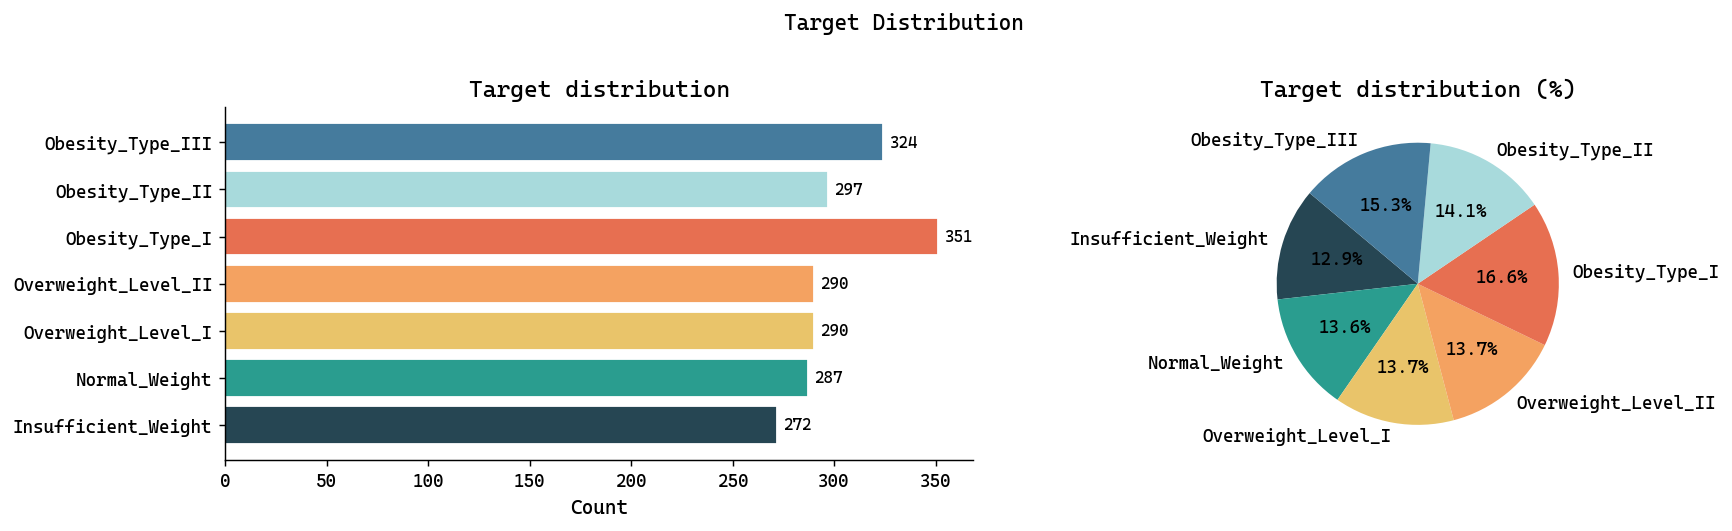

In [11]:
# target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# bar chart representation
# for numerical info
counts = df["NObeyesdad"].value_counts().reindex(TARGET_ORDER)
axes[0].barh(TARGET_ORDER, counts.values, color=[CAT_COLORS[c] for c in TARGET_ORDER], edgecolor="white")
axes[0].set_xlabel("Count")
axes[0].set_title("Target distribution")
for i, v in enumerate(counts.values):
    axes[0].text(v + 3, i, str(v), va="center", fontsize=9)

# pie chart representation for percentage info
pct = counts / counts.sum() * 100
axes[1].pie(pct.values, labels=TARGET_ORDER, colors=[CAT_COLORS[c] for c in TARGET_ORDER], autopct="%1.1f%%", startangle=140)
axes[1].set_title("Target distribution (%)")

plt.suptitle('Target Distribution', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_STORE_PATH}/target_distribution.png', bbox_inches='tight')
plt.show()


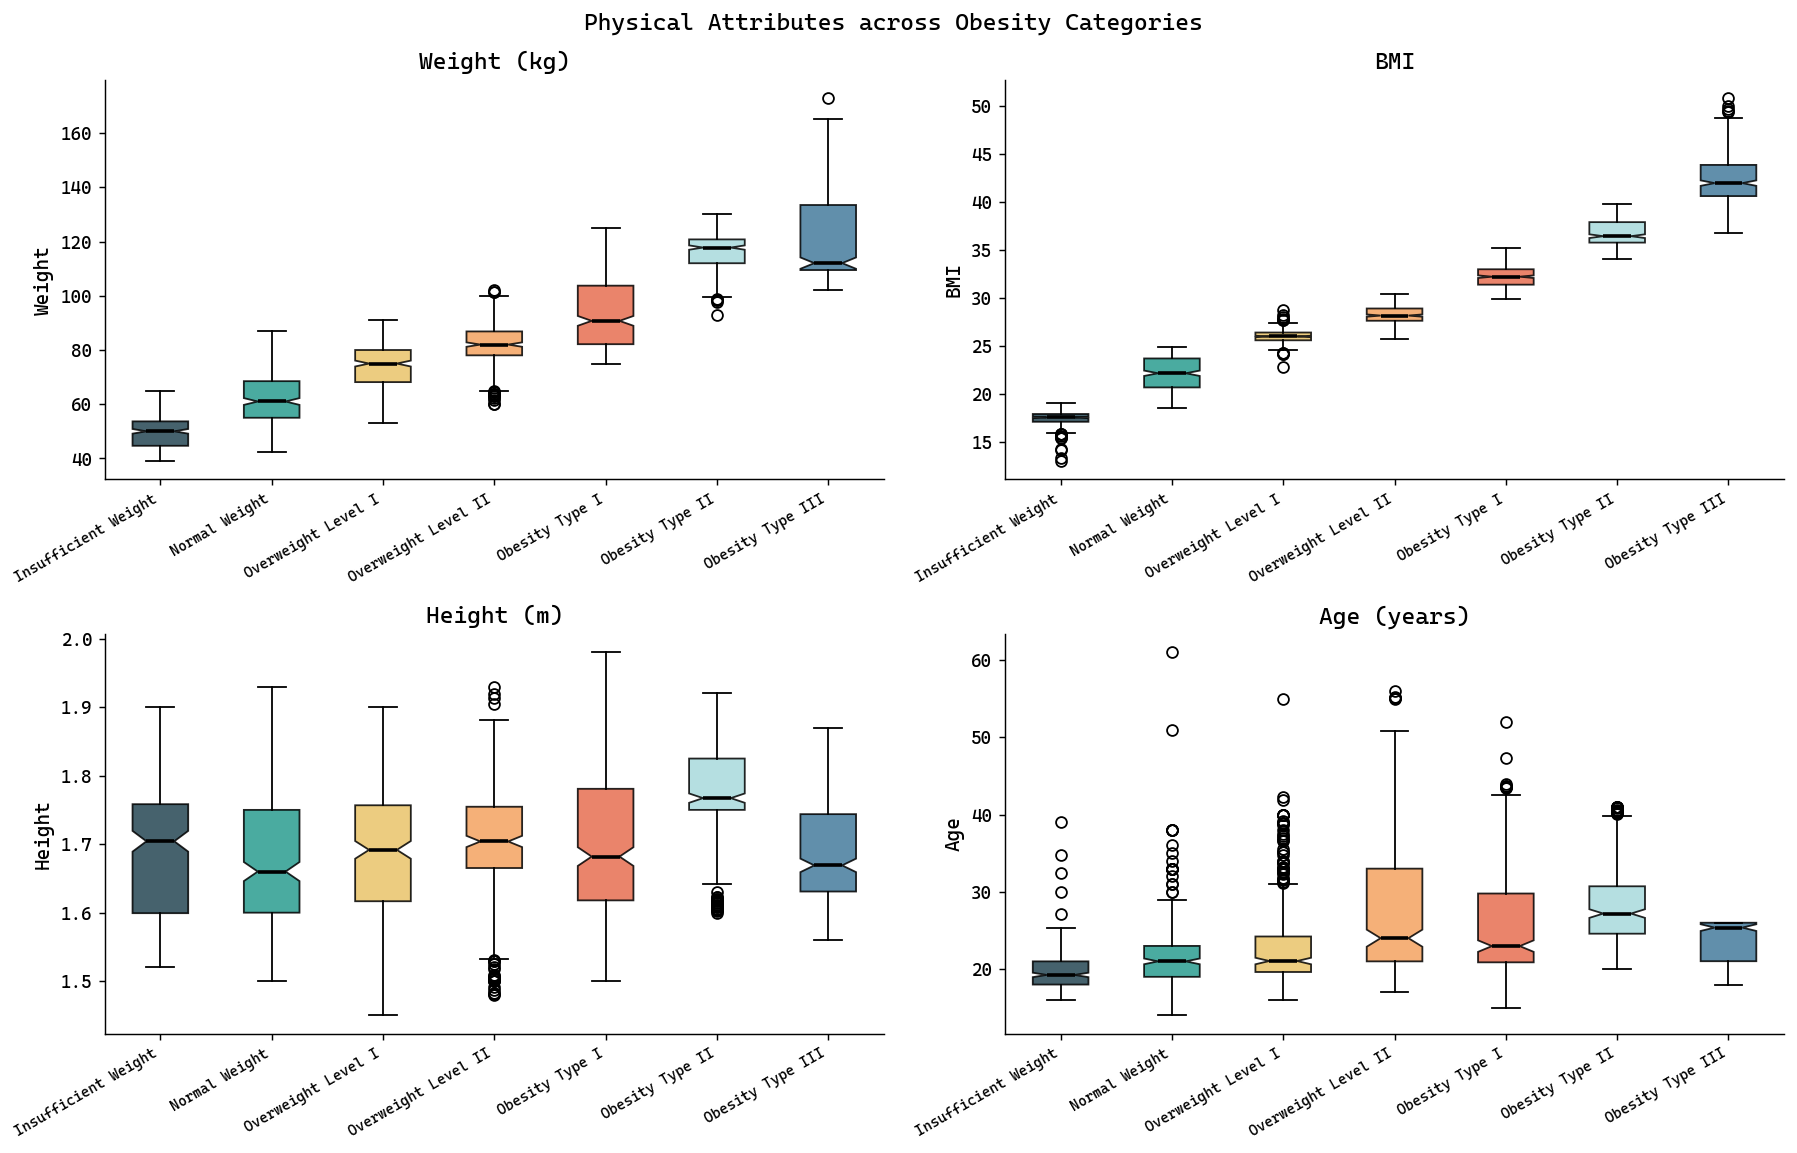

In [13]:
# BMI
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, title in zip(
    axes.flat,
    ['Weight', 'BMI', 'Height', 'Age'],
    ['Weight (kg)', 'BMI', 'Height (m)', 'Age (years)']
):
    data = [df.loc[df['NObeyesdad']==cat, col].values for cat in TARGET_ORDER]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, cat in zip(bp['boxes'], TARGET_ORDER):
        patch.set_facecolor(CAT_COLORS[cat])
        patch.set_alpha(0.85)
    ax.set_xticklabels([c.replace('_',' ') for c in TARGET_ORDER], rotation=30, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel(col)

plt.suptitle('Physical Attributes across Obesity Categories', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURE_STORE_PATH}/physical_attributes_boxplots.png', bbox_inches='tight')
plt.show()

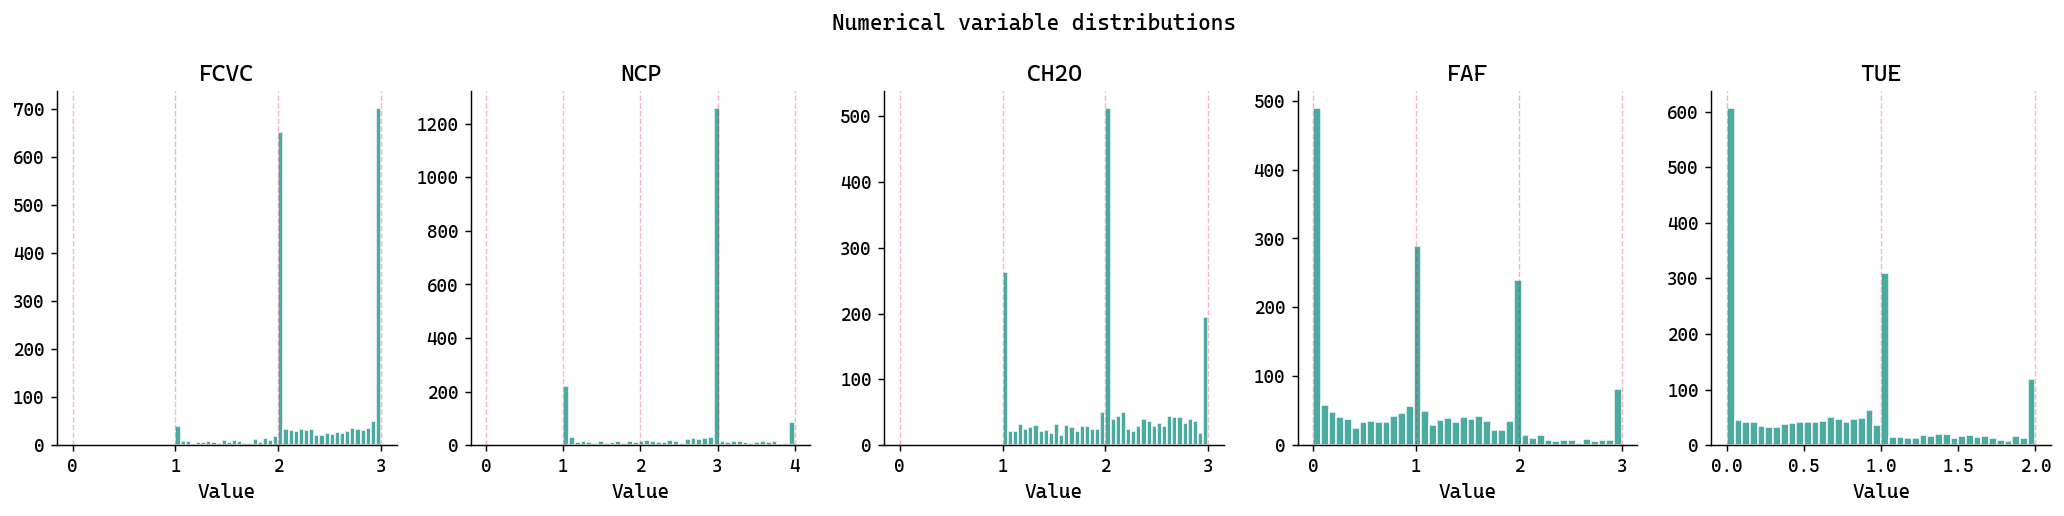

In [13]:
# check for synthetic dataset quality
behav_num = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, behav_num):
    ax.hist(df[col], bins=40, color='#2a9d8f', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Value')
    for iv in np.arange(0, df[col].max()+1):
        ax.axvline(iv, color='crimson', alpha=0.3, lw=0.8, ls='--')

plt.suptitle('Numerical variable distributions', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURE_STORE_PATH}/synthetic_dataset_check.png', bbox_inches='tight')
plt.show()

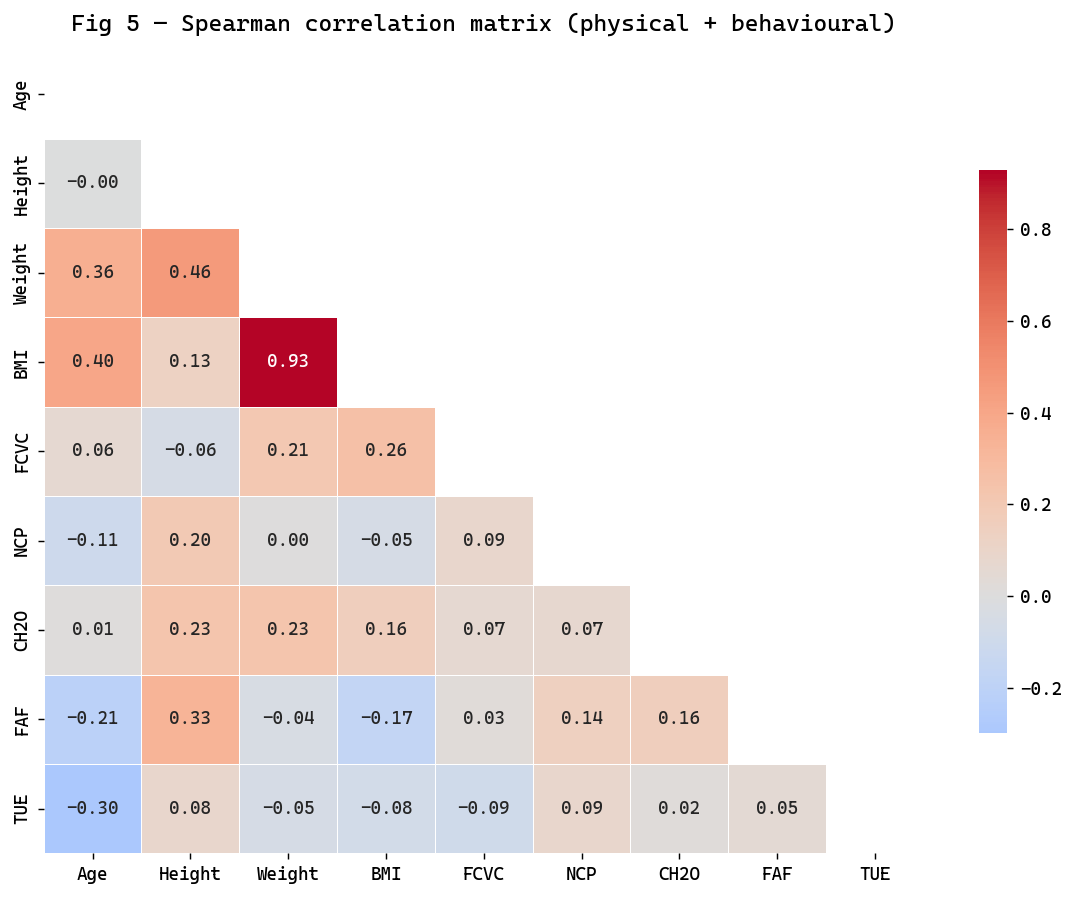

In [14]:
# Cross-behaviour heatmap: Spearman correlations
corr_cols = ['Age','Height','Weight','BMI','FCVC','NCP','CH2O','FAF','TUE']
corr = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, cbar_kws={'shrink':0.7})
ax.set_title('Fig 5 — Spearman correlation matrix (physical + behavioural)', pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURE_STORE_PATH}/correlation_heatmap.png', bbox_inches='tight')
plt.show()

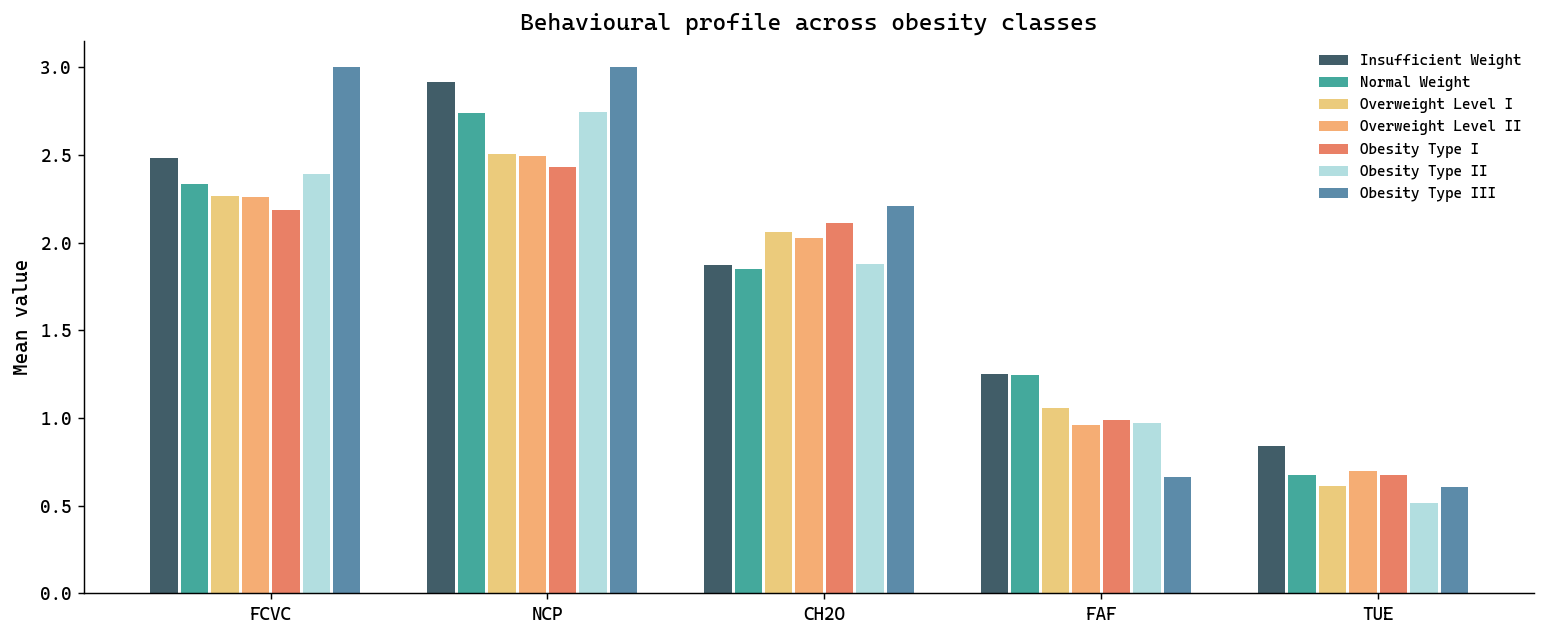

In [14]:
# behavioural profile
profile_cols = ['FCVC','NCP','CH2O','FAF','TUE']
profiles = df.groupby('NObeyesdad')[profile_cols].mean().reindex(TARGET_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(profile_cols))
width = 0.11
for i, (cat, row) in enumerate(profiles.iterrows()):
    offset = (i - len(TARGET_ORDER)/2) * width
    ax.bar(x + offset, row.values, width=width*0.9,
           color=CAT_COLORS[cat], label=cat.replace('_',' '), alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(profile_cols)
ax.set_ylabel('Mean value')
ax.set_title('Behavioural profile across obesity classes')
ax.legend(fontsize=8, loc='upper right', frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGURE_STORE_PATH}/behavioural_profile.png', bbox_inches='tight')
plt.show()